C:\Users\johri\AppData\Local\Temp\ipykernel_43828\3911879601.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({


Decision Tree Test Error = 19713.253141963352


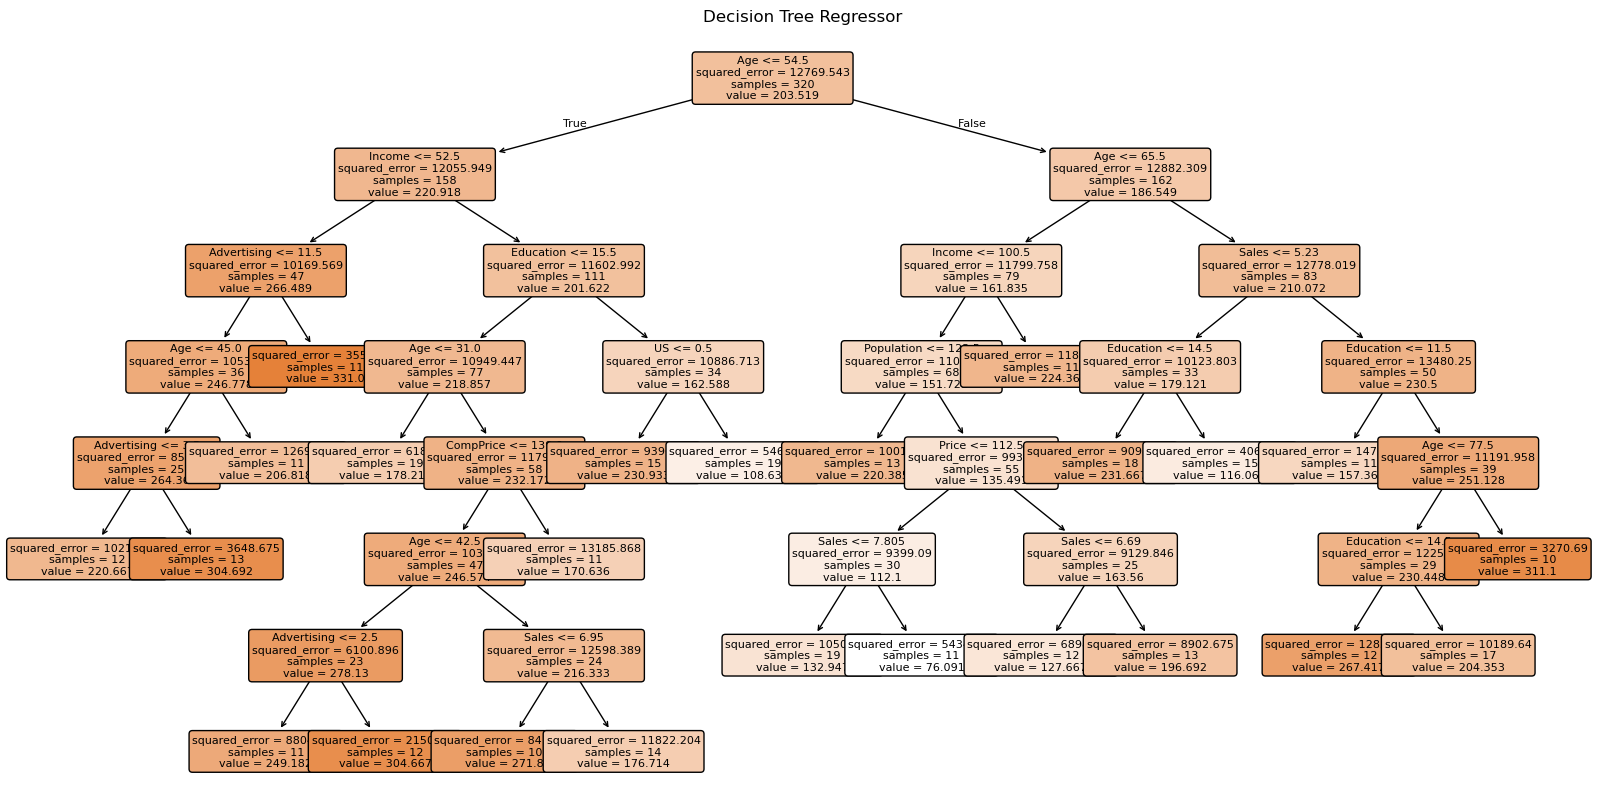

Random Forest Test Error = 15278.47635375


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# =====================================================
# Load Data
# =====================================================
df = pd.read_csv("Carseats.csv")

# -----------------------------------------------------
# Convert words to numbers
# -----------------------------------------------------
df = df.replace({
    "Good": 1,
    "Medium": 0,
    "Bad": -1,
    "Yes": 1,
    "No": 0
})

# =====================================================
# Separate dependent and independent variables
# =====================================================
X = df.iloc[:, 1:]   # all columns except first
y = df.iloc[:, 0]    # Sales

# =====================================================
# (a) Train-Test Split (80%-20%)
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.80,
    random_state=42
)

# =====================================================
# (b) Decision Tree Regressor
# No max depth
# split until 10 points in each node
# =====================================================
tree = DecisionTreeRegressor(
    min_samples_leaf=10,
    random_state=42
)

tree.fit(X_train, y_train)

# Predictions
y_pred_tree = tree.predict(X_test)

# Test Error (MSE)
test_error_tree = mean_squared_error(y_test, y_pred_tree)

print("Decision Tree Test Error =", test_error_tree)

# -----------------------------------------------------
# Plot Tree
# -----------------------------------------------------
plt.figure(figsize=(20,10))
plot_tree(
    tree,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Regressor")
plt.show()

# =====================================================
# (c) Random Forest Regressor
# B = 100 trees
# choose 4 out of 10 variables at each split
# =====================================================
rf = RandomForestRegressor(
    n_estimators=100,     # B = 100
    max_features=4,       # choose 4 variables
    random_state=42
)

rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Test Error (MSE)
test_error_rf = mean_squared_error(y_test, y_pred_rf)

print("Random Forest Test Error =", test_error_rf)

In [7]:
help(DecisionTreeRegressor)

Help on class DecisionTreeRegressor in module sklearn.tree._classes:

class DecisionTreeRegressor(sklearn.base.RegressorMixin, BaseDecisionTree)
 |  DecisionTreeRegressor(
 |      *,
 |      criterion='squared_error',
 |      splitter='best',
 |      max_depth=None,
 |      min_samples_split=2,
 |      min_samples_leaf=1,
 |      min_weight_fraction_leaf=0.0,
 |      max_features=None,
 |      random_state=None,
 |      max_leaf_nodes=None,
 |      min_impurity_decrease=0.0,
 |      ccp_alpha=0.0,
 |      monotonic_cst=None
 |  )
 |
 |  A decision tree regressor.
 |
 |  Read more in the :ref:`User Guide <tree>`.
 |
 |  Parameters
 |  ----------
 |  criterion : {"squared_error", "friedman_mse", "absolute_error",             "poisson"}, default="squared_error"
 |      The function to measure the quality of a split. Supported criteria
 |      are "squared_error" for the mean squared error, which is equal to
 |      variance reduction as feature selection criterion and minimizes the L2
 | 